In [1]:
import copy, math
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("./deeplearning.mplstyle")
np.set_printoptions(precision = 2)

In [2]:
X_train = np.array([[2104, 5, 1, 45], [1416, 3, 2, 40], [852, 2, 1, 35]])
y_train = np.array([460, 232, 178])

In [3]:
#display the input data
#data is stored in NumPy array/matrix
print(f"X Shape: {X_train.shape}, X type: {type(X_train)}")
print(X_train)
print(f"y Shape: {y_train.shape}, y type: {type(y_train)}")
print(y_train)

X Shape: (3, 4), X type: <class 'numpy.ndarray'>
[[2104    5    1   45]
 [1416    3    2   40]
 [ 852    2    1   35]]
y Shape: (3,), y type: <class 'numpy.ndarray'>
[460 232 178]


In [10]:
b_init = 785.1811367994083
w_init = np.array([0.39133535, 18.75376741, -53.36032453, -26.42131618])
print(f"w_init Shape: {w_init.shape} \n w_init Type: {type(w_init)} \n b_init Type: {type(b_init)}")
print(w_init, "\n", b_init)

w_init Shape: (4,) 
 w_init Type: <class 'numpy.ndarray'> 
 b_init Type: <class 'float'>
[  0.39  18.75 -53.36 -26.42] 
 785.1811367994083


## SINGLE PREDICTION ELEMENT BY ELEMENT

In [29]:
def predict_single_loop(x, w, b):
    """
    Single predict using linear regression
    Args:
        x (ndarray): Shape (n,) example with multiple features
        w (ndarray): Shape (n,) model patameter
        b (scalar): model parameter
    Returns: 
        p (scalar): prediction
    """
    n = x.shape[0]
    p = 0
    for i in range (n):
        p_i = x[i] * w[i]
        p += p_i
    p += b
    return p

In [30]:
#get a row from one training data
x_vec = X_train[0, :]
print(f"x_vec Shape: {x_vec.shape} \nx_vec value: {x_vec}")

x_vec Shape: (4,) 
x_vec value: [2104    5    1   45]


In [31]:
#make a prediction
f_wb = predict_single_loop(x_vec, w_init, b_init)
print(f"f_wb Shape: {f_wb.shape} \nf_wb Value: {f_wb}")

f_wb Shape: () 
f_wb Value: 459.9999976194083


## SINGLE PREDICTION USING VECTOR

In [32]:
def predict(x, w, b):
    p = np.dot(x,w) + b
    return p

In [33]:
#get a row from one training data
x_vec = X_train[0, :]
print(f"x_vec Shape: {x_vec.shape} \nx_vec value: {x_vec}")

x_vec Shape: (4,) 
x_vec value: [2104    5    1   45]


In [34]:
#make a prediction
f_wb_ = predict(x_vec, w_init, b_init)
print(f"f_wb Shape: {f_wb_.shape} \nf_wb Value: {f_wb_}")

f_wb Shape: () 
f_wb Value: 459.9999976194083


## COMPUTE COST WITH MULTIPLE VARIABLES

In [39]:
def compute_cost(X, y, w, b):
    """
    Compute cost
    Args:
        X (ndarray (m,n)): data, m examples with n features
        y (ndarray (m,)): target values
        w (ndarray (n,)): model parameter
        b (scalar): model parameter
    Returns:
        cost (scalar): Cost
    """
    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        f_wb_i = np.dot(X[i], w) + b
        cost = cost + (f_wb_i - y[i]) ** 2
    cost = cost / (2 * m)
    return cost

In [40]:
#compute & display cost
cost = compute_cost(X_train, y_train, w_init, b_init)
print(f"Cost at optimal w: {cost}")

Cost at optimal w: 1.5578904045996674e-12


## COMPUTE GRADIENT WITH MULTIPLE VARIABLES

In [51]:
def compute_gradient(X, y, w, b):
    """
    Computes gradient for linear regression
    Args:
        X (ndarray (m,n)): data, m examples with n features
        y (ndarray (m,)): target values
        w (ndarray (n,)): model parameter
        b (scalar): model parameter
    Returns:
        dj_dw (ndarray (n,)): gradient of cost w.r.t. w
        dj_db (ndarray (n,)): gradient of cost w.r.t. b
    """
    m, n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.
    for i in range(m):
        err = (np.dot(X[i], w) + b) - y[i]
        for j in range(n):
            dj_dw[j] += err * X[i,j]
        dj_db += err
    dj_dw /= m
    dj_db /= m

    return dj_dw, dj_db

In [52]:
#compute & display gradient
tmp_dj_dw, tmp_dj_db = compute_gradient(X_train, y_train, w_init, b_init)
print(f"dj_dw at initial w, b: \n{tmp_dj_dw}")
print(f"dj_db at initial w, b: \n{tmp_dj_db}")

dj_dw at initial w, b: 
[-2.73e-03 -6.27e-06 -2.22e-06 -6.92e-05]
dj_db at initial w, b: 
-1.6739251122999121e-06


## GRADIENT DESCENT WITH MULTIPLE VARIABLES

In [85]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):
    """
    Performs batch gradient descent to learn w and b. Updates w and b by taking num_iters gradient steps with learning rate alpha
    Args:
        X (ndarray (m,n)): data, m examples with n features
        y (ndarray (m,)): target values
        w_in (ndarray (n,)): model parameter
        b_in (scalar): model parameter
        cost_function: function to compute cost
        gradient_function: function to compute gradient
        alpha (float): learning rate
        num_iters (int): no. of iterations to run gradient descent
        
    Returns:
        w (ndarray, (n,)): updated values of parameters
        b (scalar): updated values of parameters
    """
    #an array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    w = copy.deepcopy(w_in)
    b = b_in
    for i in range(num_iters):
        #calculate the gradient and update parameter
        dj_dw, dj_db = gradient_function(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        #save cost J at each iterations
        if i < 1000000:
            J_history.append(cost_function(X, y, w, b))

        #print cost at every interval of 10 iterations
        if i % math.ceil(num_iters / 10) == 0:
            print(f"Iterations {i}: Cost: {J_history[-1]}")
    return w, b, J_history

In [92]:
#initialize parameters
initial_w = np.zeros_like(w_init)
initial_b = 0.0
iterations = 200000
alpha = 5.0e-7
w_final, b_final, J_hist = gradient_descent(X_train, y_train, initial_w, initial_b, compute_cost, compute_gradient, alpha, iterations)
print(f"w, b found by gradient descent: {w_final}, {b_final : 0.2f}")


Iterations 0: Cost: 2529.4629522316304
Iterations 20000: Cost: 594.3333440477821
Iterations 40000: Cost: 574.732192894754
Iterations 60000: Cost: 569.1797876455938
Iterations 80000: Cost: 566.0102450017911
Iterations 100000: Cost: 563.2537571994991
Iterations 120000: Cost: 563.2537571994991
Iterations 140000: Cost: 563.2537571994991
Iterations 160000: Cost: 563.2537571994991
Iterations 180000: Cost: 563.2537571994991
w, b found by gradient descent: [ 0.24  0.56 -1.62 -1.55], -0.03


In [93]:
m, _ = X_train.shape
for i in range (m):
    print(f"Prediction: {np.dot(X_train[i], w_final) + b_final : 0.2f}, target value: {y_train[i]}")

Prediction:  439.69, target value: 460
Prediction:  278.44, target value: 232
Prediction:  150.97, target value: 178


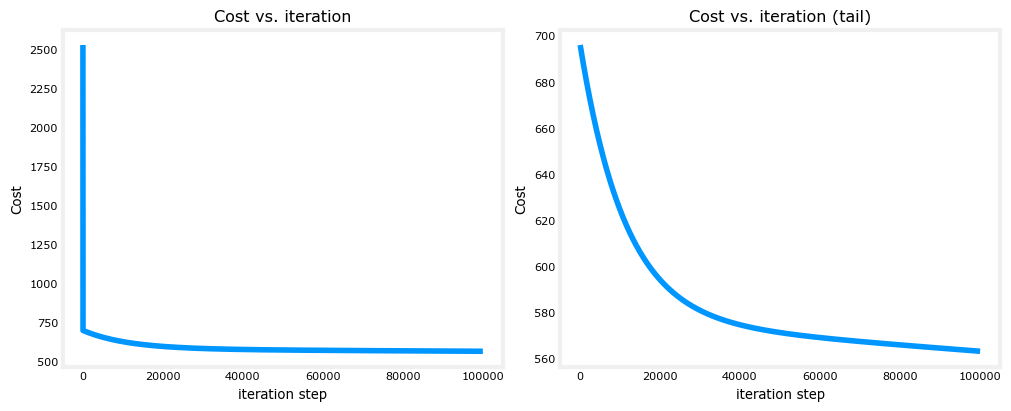

In [94]:
#plot of cost vs iteration
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout = True, figsize = (10, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100 : ])), J_hist[100 : ])
ax1.set_title("Cost vs. iteration")
ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             
ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   
ax2.set_xlabel('iteration step') 
plt.show()